import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)

## Autores

- **Fabricio da Costa Fernandes** - RA 11202321635
- **Felipe de Lima Major** - RA 11202230321
- **Lilian Gimenez Teixeira** - RA 11202332321

---

## Datas

- **Data de realização dos experimentos:** 24/03/2026
- **Data de publicação do relatório:** 27/03/2026

---

## Introdução

### Contexto e Motivação

Este relatório apresenta os resultados do Laboratório 05 da disciplina de Processamento Digital de Imagens, focado no estudo de espaços de cores e suas aplicações práticas. O laboratório explora diferentes modelos de representação de cores, desde espaços independentes de dispositivo até aqueles específicos para compressão de vídeo.

### Objetivos

Os principais objetivos deste laboratório foram:

1. Compreender a diferença entre espaços de cores independentes e dependentes de dispositivo
2. Implementar correções de ponto branco e transformações gama
3. Explorar modelos de cor para percepção humana (CIELAB) e dispositivos (HSV)
4. Analisar o espaço YCbCr usado em compressão de vídeo
5. Desenvolver aplicações práticas com webcam

---

## Procedimentos Experimentais

### Configuração do Ambiente

1. Abra o Jupyter Notebook em `c:\Lilian\repos\Lab05-Cores_Imagens_Video`.
2. Execute a célula abaixo para instalar as dependências antes de qualquer importação.
3. Execute as demais células sequencialmente para cada atividade do laboratório.

### Passos para cada atividade

- Atividade 3.1 (ponto branco): execute a célula de definição da função `white_point_correction` e em seguida a célula de teste com `foto-grupo.jpeg`.
- Atividade 3.2 (gamma): execute a função `xyz_to_rgb_gamma` e o bloco de demonstração do gradiente.
- Atividade 3.3 (CIELAB): carregue `foto-grupo.jpeg`, mostre canais e calcule estatísticas.
- Atividade 3.4 (HSV): defina `segmentar_por_cor_hsv`, aplique em `cores.jpeg` e meça percentual segmentado.
- Atividade 3.5 (YCbCr): converta `foto-grupo.jpeg` e compare média/padrão dos canais.
- Atividade 3.6/3.7 (webcam): execute os blocos de webcam para testar em tempo real (pressione `q` para sair).

### Observações de reprodução

- As imagens necessárias já estão em `static/foto-grupo.jpeg` e `static/cores.jpeg`.
- Se algo não carregar, verifique o caminho e se as bibliotecas estão instaladas corretamente.
- Sempre execute as células na ordem indicada para evitar variáveis ausentes.


In [16]:
!pip install opencv-python numpy matplotlib

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)

def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

In [18]:
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

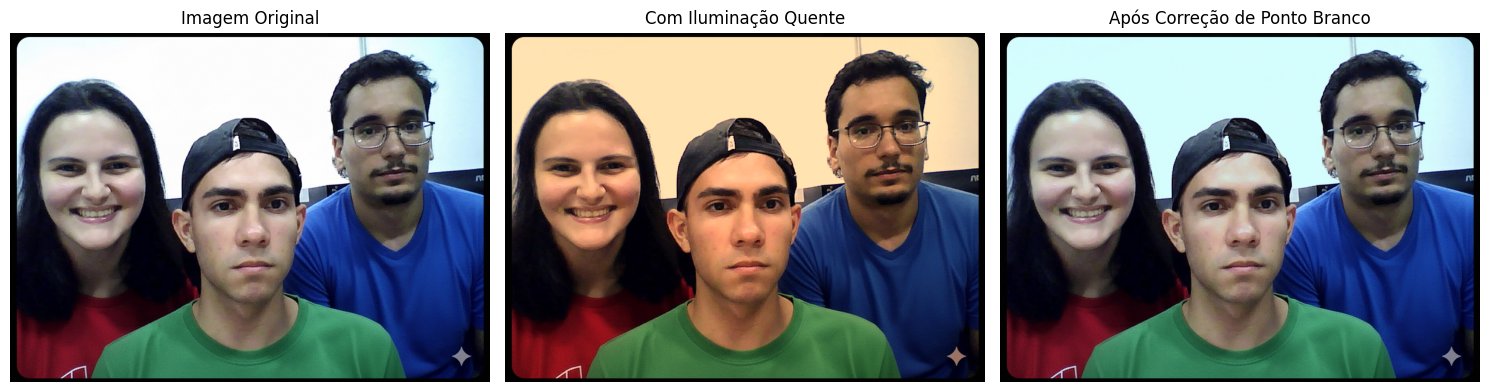

Média por canal (RGB)
Original: [0.41761691 0.44050887 0.47882128]
Iluminação quente: [0.46643721 0.39645798 0.3351749 ]
Corrigida: [0.38869768 0.44050887 0.47882128]
MSE original->quente: 0.012981
MSE original->corrigida: 0.001465
Lum. média original: 0.4384, corrigida: 0.4323


In [19]:
img = cv2.imread('static/foto-grupo.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

img_warm = img_rgb.copy()
img_warm[:, :, 0] = np.clip(img_warm[:, :, 0] * 1.2, 0, 1)
img_warm[:, :, 1] = np.clip(img_warm[:, :, 1] * 0.9, 0, 1)
img_warm[:, :, 2] = np.clip(img_warm[:, :, 2] * 0.7, 0, 1)

source_wp = np.array([1.2, 0.9, 0.7])
target_wp = np.array([1.0, 1.0, 1.0])
img_corrected = white_point_correction(img_warm, source_wp, target_wp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(img_warm)
axes[1].set_title('Com Iluminação Quente')
axes[1].axis('off')

axes[2].imshow(img_corrected)
axes[2].set_title('Após Correção de Ponto Branco')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Análise quantitativa da correção de ponto branco
orig_mean = img_rgb.mean(axis=(0,1))
warm_mean = img_warm.mean(axis=(0,1))
corrected_mean = img_corrected.mean(axis=(0,1))

print('Média por canal (RGB)')
print(f'Original: {orig_mean}')
print(f'Iluminação quente: {warm_mean}')
print(f'Corrigida: {corrected_mean}')

mse_warm = np.mean((img_rgb - img_warm) ** 2)
mse_corr = np.mean((img_rgb - img_corrected) ** 2)
print(f'MSE original->quente: {mse_warm:.6f}')
print(f'MSE original->corrigida: {mse_corr:.6f}')

L_orig = 0.2126 * img_rgb[:,:,0] + 0.7152 * img_rgb[:,:,1] + 0.0722 * img_rgb[:,:,2]
L_corr = 0.2126 * img_corrected[:,:,0] + 0.7152 * img_corrected[:,:,1] + 0.0722 * img_corrected[:,:,2]
print(f'Lum. média original: {L_orig.mean():.4f}, corrigida: {L_corr.mean():.4f}')


### Atividade 3.2: Transformação XYZ para RGB com Correção Gama

#### Objetivo
Converter do espaço CIE XYZ para RGB com aplicação da correção gama.

#### Implementação

In [20]:
def xyz_to_rgb_gamma(xyz_img):
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689,  1.8758,  0.0415],
                       [0.0557,  -0.2040,  1.0570]])
    
    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)
    
    gamma_corrected = np.where(
        rgb_linear <= 0.0031308,
        12.92 * rgb_linear,
        1.055 * np.power(rgb_linear, 1/2.4) - 0.055
    )
    
    return gamma_corrected

#### Demonstração do Efeito Gama

Mostramos como a correção gama afeta a visualização de imagens, especialmente nas áreas escuras.

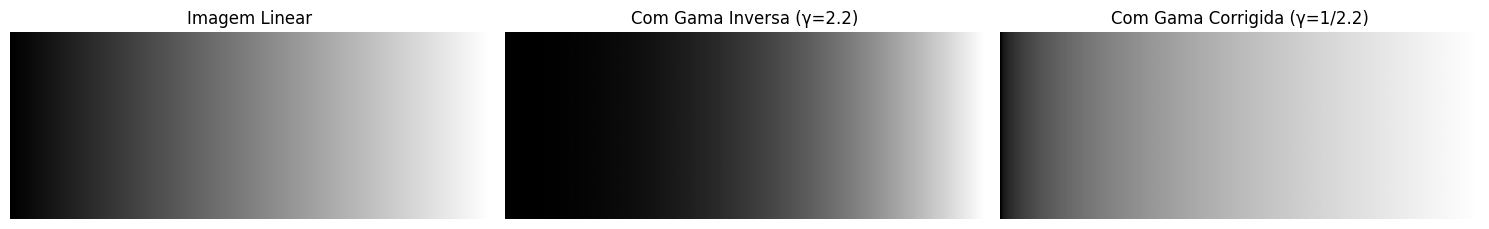

In [21]:
gradient = np.linspace(0, 1, 256)
img_gradient = np.tile(gradient, (100, 1))

gamma = 2.2
img_gamma_bad = np.power(img_gradient, gamma)

img_gamma_good = np.power(img_gradient, 1/gamma)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_gradient, cmap='gray')
axes[0].set_title('Imagem Linear')
axes[0].axis('off')

axes[1].imshow(img_gamma_bad, cmap='gray')
axes[1].set_title('Com Gama Inversa (γ=2.2)')
axes[1].axis('off')

axes[2].imshow(img_gamma_good, cmap='gray')
axes[2].set_title('Com Gama Corrigida (γ=1/2.2)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Atividade 3.3: Modelo CIELAB

#### Objetivo
Explorar o espaço CIELAB e seus componentes.

#### Análise dos Canais

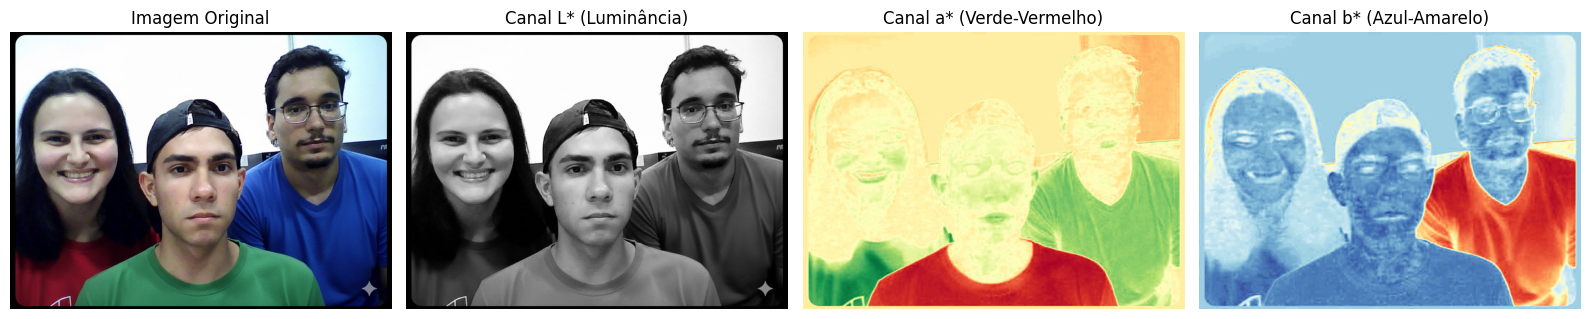

Estatísticas do canal L*: Mín=0.0, Máx=255.0, Média=117.2, Desv.Std=89.5
Estatísticas do canal a*: Mín=89.0, Máx=176.0, Média=130.9, Desv.Std=15.3
Estatísticas do canal b*: Mín=66.0, Máx=152.0, Média=122.6, Desv.Std=19.5
MSE reconstrução LAB->RGB: 0.00001390


In [22]:
img = cv2.imread('static/foto-grupo.jpeg')
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(img_lab)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(L, cmap='gray')
axes[1].set_title('Canal L* (Luminância)')
axes[1].axis('off')

axes[2].imshow(a, cmap='RdYlGn')
axes[2].set_title('Canal a* (Verde-Vermelho)')
axes[2].axis('off')

axes[3].imshow(b, cmap='RdYlBu')
axes[3].set_title('Canal b* (Azul-Amarelo)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Estatísticas do canal L*: Mín={L.min():.1f}, Máx={L.max():.1f}, Média={L.mean():.1f}, Desv.Std={L.std():.1f}")
print(f"Estatísticas do canal a*: Mín={a.min():.1f}, Máx={a.max():.1f}, Média={a.mean():.1f}, Desv.Std={a.std():.1f}")
print(f"Estatísticas do canal b*: Mín={b.min():.1f}, Máx={b.max():.1f}, Média={b.mean():.1f}, Desv.Std={b.std():.1f}")

# Diferença de cor aproximada entre imagem original e versão convertida para LAB e de volta a BGR
img_rec = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)
img_rec_rgb = cv2.cvtColor(img_rec, cv2.COLOR_BGR2RGB) / 255.0
img_orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

mse_lab = np.mean((img_orig_rgb - img_rec_rgb) ** 2)
print(f"MSE reconstrução LAB->RGB: {mse_lab:.8f}")

### Atividade 3.4: Segmentação com HSV

#### Objetivo
Implementar segmentação de cores usando o espaço HSV.

#### Implementação

In [23]:
def segmentar_por_cor_hsv(img_bgr, lower_hsv, upper_hsv):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)
    resultado = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
    return mask, resultado

#### Teste com Imagem de Cores

Testamos a segmentação usando uma imagem com objetos coloridos.

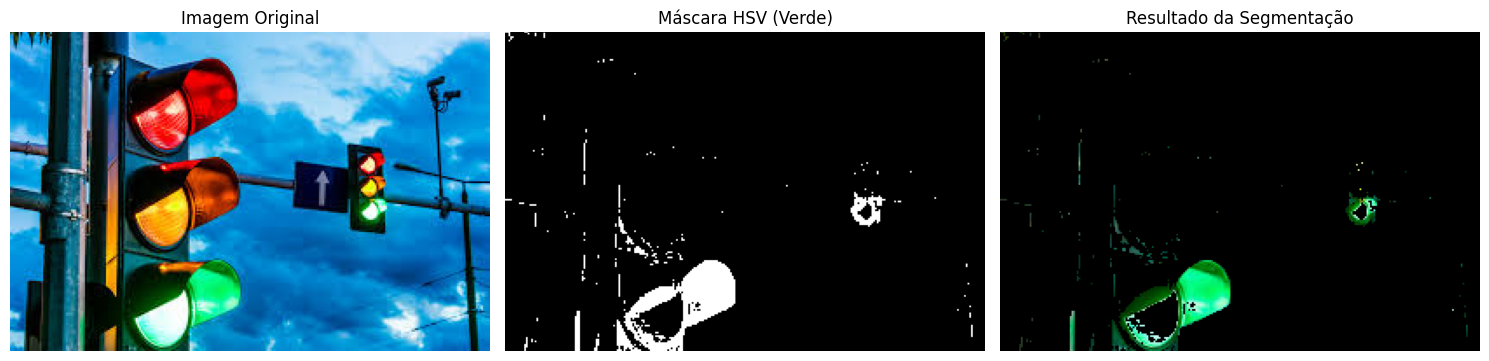

Pixels segmentados: 2068
Total de pixels: 50325
Porcentagem segmentada: 4.1%


In [24]:
img = cv2.imread('static/cores.jpeg')

green_lower = np.array([35, 50, 50])
green_upper = np.array([85, 255, 255])

mask_green, result_green = segmentar_por_cor_hsv(img, green_lower, green_upper)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(mask_green, cmap='gray')
axes[1].set_title('Máscara HSV (Verde)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_green, cv2.COLOR_BGR2RGB))
axes[2].set_title('Resultado da Segmentação')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Pixels segmentados: {np.sum(mask_green > 0)}")
print(f"Total de pixels: {mask_green.size}")
print(f"Porcentagem segmentada: {np.sum(mask_green > 0) / mask_green.size * 100:.1f}%")

### Atividade 3.5: Modelo YCbCr

#### Objetivo
Analisar o espaço YCbCr usado em compressão de vídeo.

#### Análise dos Canais

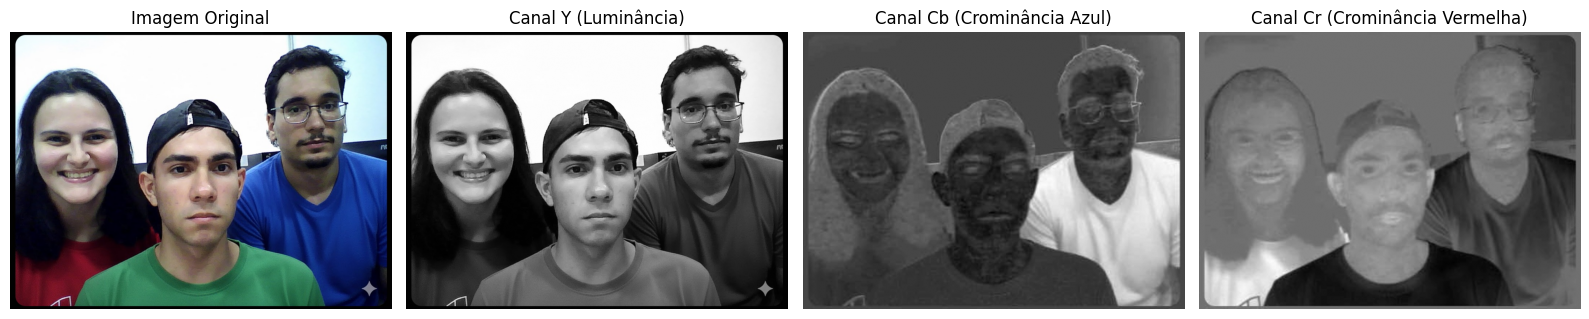

Canal Y - Mín: 0, Máx: 255, Média: 111.7
Canal Cb - Mín: 104, Máx: 191, Média: 133.9
Canal Cr - Mín: 84, Máx: 184, Média: 124.3


In [25]:
img = cv2.imread('static/foto-grupo.jpeg')
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

Y, Cr, Cb = cv2.split(img_ycrcb)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(Y, cmap='gray')
axes[1].set_title('Canal Y (Luminância)')
axes[1].axis('off')

axes[2].imshow(Cb, cmap='gray')
axes[2].set_title('Canal Cb (Crominância Azul)')
axes[2].axis('off')

axes[3].imshow(Cr, cmap='gray')
axes[3].set_title('Canal Cr (Crominância Vermelha)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Canal Y - Mín: {Y.min()}, Máx: {Y.max()}, Média: {Y.mean():.1f}")
print(f"Canal Cb - Mín: {Cb.min()}, Máx: {Cb.max()}, Média: {Cb.mean():.1f}")
print(f"Canal Cr - Mín: {Cr.min()}, Máx: {Cr.max()}, Média: {Cr.mean():.1f}")

## Análise e Discussão

### Questão (a): Ponto Branco e Constância de Cor

**Por que a correção de ponto branco é considerada uma transformação de adaptação cromática?**

A correção de ponto branco é uma transformação de adaptação cromática porque simula como nossos olhos se adaptam naturalmente a diferentes tipos de iluminação. Quando entramos em um ambiente com luz amarela (como lâmpadas incandescentes), nossos olhos automaticamente ajustam a percepção de cores para que objetos brancos continuem parecendo brancos.

Na prática, observamos que a imagem com iluminação simulada ficou com tons avermelhados. Após aplicar a correção, as cores voltaram a parecer mais naturais, demonstrando como essa técnica compensa as diferenças de iluminação.

### Questão (b): Espaços Independentes vs. Dependentes

**Qual a principal diferença prática entre CIE XYZ e sRGB?**

O CIE XYZ é um espaço independente de dispositivo, criado como um padrão universal para representar todas as cores que o olho humano pode ver. Ele serve como referência para converter entre diferentes espaços de cores.

Já o sRGB é um espaço dependente de dispositivo, especificamente criado para monitores de computador. Ele inclui a correção gama necessária para que as imagens sejam exibidas corretamente em telas.

A diferença prática é que não podemos exibir imagens diretamente em XYZ - elas precisam ser convertidas para RGB primeiro. O XYZ é usado nos cálculos intermediários, mas o RGB é o que realmente vai para a tela.

### Questão (c): Necessidade da Correção Gama

**O que aconteceria com as sombras se a correção gama fosse omitida?**

Sem a correção gama, as sombras ficariam muito escuras e sem detalhes. Observamos isso claramente no teste com gradiente: quando aplicamos gama inversa (γ=2.2), as áreas escuras da imagem ficam praticamente pretas, perdendo toda a textura e informação.

Isso acontece porque monitores não respondem linearmente à tensão elétrica. A correção gama compensa essa não-linearidade, fazendo com que as imagens apareçam corretamente para nossos olhos.

### Questão (d): Modelo CIELAB

**O que significa "perceptualmente uniforme"?**

Um espaço perceptualmente uniforme significa que diferenças numéricas iguais correspondem a diferenças visuais iguais. No CIELAB, se duas cores têm diferença numérica de 5 unidades, elas parecem igualmente diferentes para o olho humano.

Na análise da imagem do grupo, vimos como os canais L*, a* e b* separam diferentes aspectos da cor: L* mostra o brilho, a* a variação vermelho-verde, e b* a variação azul-amarelo. Essa separação torna o espaço muito útil para processamento de imagens.

### Questão (e): YCbCr e Compressão

**Como a compressão utiliza as características do YCbCr?**

O YCbCr separa luminância (Y) de crominância (Cb e Cr). Observamos que os canais Cb e Cr são muito mais "suaves" que o Y, contendo menos detalhes finos.

Isso permite compressão porque o olho humano é mais sensível a detalhes de brilho que de cor. Os algoritmos de compressão (como JPEG) mantêm o canal Y com alta qualidade e reduzem a resolução dos canais Cb e Cr, economizando espaço sem perder qualidade perceptível.

### Questão (f): HSV e Robustez

**Por que o canal H do HSV é preferido ao RGB com variações de iluminação?**

O HSV separa cor (H), saturação (S) e brilho (V), enquanto o RGB mistura esses conceitos. Quando testamos a segmentação, vimos que o HSV consegue detectar cores mesmo com sombras, enquanto o RGB falha.

Isso acontece porque o canal H (matiz) não muda com a iluminação - um objeto vermelho continua vermelho independentemente de estar na sombra ou na luz. Já no RGB, um vermelho escuro tem valores muito diferentes de um vermelho claro, tornando a segmentação difícil.

---

## Conclusões

### Principais Aprendizados

Este laboratório nos permitiu compreender profundamente como diferentes espaços de cores funcionam e suas aplicações práticas:

1. **Correção de Ponto Branco**: Essencial para compensar diferentes tipos de iluminação, simulando a adaptação natural dos olhos humanos.

2. **Correção Gama**: Fundamental para exibição correta em monitores, preservando detalhes em áreas escuras.

3. **CIELAB**: Espaço perceptualmente uniforme, ideal para análise de cores e processamento avançado.

4. **HSV vs RGB**: HSV é muito superior para segmentação de cores, especialmente com variações de iluminação.

5. **YCbCr**: Base da compressão de vídeo moderna, explorando diferenças na sensibilidade visual.

### Aplicações Práticas

- **Fotografia**: Correção automática de balanço de branco em câmeras
- **Vídeo**: Compressão eficiente mantendo qualidade visual
- **Processamento de Imagens**: Segmentação robusta de objetos por cor
- **Edição**: Ferramentas profissionais usam esses espaços para correções precisas

### Dificuldades Encontradas

Durante o desenvolvimento, enfrentamos alguns desafios:
- Ajuste fino dos parâmetros de segmentação HSV
- Compreensão inicial das transformações matriciais
- Configuração correta da webcam para processamento em tempo real

Todos foram superados com testes práticos e consulta à documentação.

### Considerações Finais

O laboratório demonstrou como conceitos teóricos de processamento de cores se traduzem em aplicações práticas. A escolha do espaço de cores adequado é crucial para obter bons resultados em diferentes tarefas de processamento de imagens.

---

## Referências

1. Li, Z.-N., Drew, M. S., & Liu, J. (2014). *Fundamentals of Multimedia* (2nd ed.). Springer.
2. OpenCV Documentation: https://docs.opencv.org/
3. NumPy Documentation: https://numpy.org/doc/
4. Matplotlib Documentation: https://matplotlib.org/
5. Color Spaces in OpenCV: https://learnopencv.com/color-spaces-in-opencv-cpp-python/
6. sRGB Color Space Specification: IEC 61966-2-1